# Hilbert Spaces

## From Inner Products to Completeness: Geometry in Infinite Dimensions

Hilbert spaces are the natural generalization of Euclidean geometry to infinite-dimensional settings. They combine the algebraic structure of an **inner product** with the topological property of **completeness**, giving us a framework where geometric intuition (angles, projections, orthogonality) carries over from $\mathbb{R}^n$ to spaces of functions and sequences.

This notebook builds the theory from the ground up:

1. **Inner Product Spaces** — axioms, Cauchy-Schwarz, parallelogram law
2. **Hilbert Spaces** — completeness + inner product, key examples
3. **Orthogonality & Orthonormal Bases** — Gram-Schmidt, Legendre polynomials
4. **Projection Theorem & Best Approximation** — Fourier series as projection
5. **Riesz Representation Theorem** — duality $H \cong H^*$
6. **Bessel's Inequality & Parseval's Identity** — energy conservation

**Prerequisites**: Linear algebra (inner products, orthogonality in $\mathbb{R}^n$), basic real analysis (convergence, completeness), familiarity with function spaces.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from scipy import integrate
from scipy.special import legendre
import warnings
warnings.filterwarnings('ignore')

In [2]:
# ── Global constants ──────────────────────────────────────────────────────────
FIGSIZE       = (10, 6)
FIGSIZE_WIDE  = (14, 6)
FIGSIZE_TALL  = (10, 8)
FIGSIZE_SMALL = (8, 5)

# Color palette
C_BLUE    = '#2196F3'
C_RED     = '#F44336'
C_GREEN   = '#4CAF50'
C_ORANGE  = '#FF9800'
C_PURPLE  = '#9C27B0'
C_TEAL    = '#009688'
C_PINK    = '#E91E63'
C_GREY    = '#607D8B'
PALETTE   = [C_BLUE, C_RED, C_GREEN, C_ORANGE, C_PURPLE, C_TEAL, C_PINK, C_GREY]

# Matplotlib defaults
plt.rcParams.update({
    'figure.figsize': FIGSIZE,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 12,
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'legend.fontsize': 11,
    'lines.linewidth': 2,
})

---

## 1. Inner Product Spaces

### 1.1 Definition and Axioms

An **inner product** on a vector space $V$ over $\mathbb{F}$ (where $\mathbb{F} = \mathbb{R}$ or $\mathbb{C}$) is a map $\langle \cdot, \cdot \rangle : V \times V \to \mathbb{F}$ satisfying:

| Axiom | Statement | Meaning |
|-------|-----------|--------|
| **Linearity** (1st argument) | $\langle \alpha x + \beta y, z \rangle = \alpha \langle x, z \rangle + \beta \langle y, z \rangle$ | Linear in first slot |
| **Conjugate symmetry** | $\langle x, y \rangle = \overline{\langle y, x \rangle}$ | Swap with conjugate |
| **Positive definiteness** | $\langle x, x \rangle \geq 0$ with equality iff $x = 0$ | Length is non-negative |

For real vector spaces, conjugate symmetry reduces to plain symmetry: $\langle x, y \rangle = \langle y, x \rangle$.

The inner product **induces a norm**:

$$\|x\| = \sqrt{\langle x, x \rangle}$$

A vector space equipped with an inner product is called an **inner product space** (or pre-Hilbert space).

### 1.2 Cauchy-Schwarz Inequality

**Theorem (Cauchy-Schwarz).** For any $x, y$ in an inner product space,

$$|\langle x, y \rangle| \leq \|x\| \cdot \|y\|$$

with equality if and only if $x$ and $y$ are linearly dependent.

**Proof.** If $y = 0$ the inequality is trivially true. Otherwise, for any $t \in \mathbb{R}$:

$$0 \leq \|x - ty\|^2 = \langle x - ty, x - ty \rangle = \|x\|^2 - 2t\,\text{Re}\langle x, y\rangle + t^2\|y\|^2$$

This is a quadratic in $t$ that is non-negative, so its discriminant must be $\leq 0$:

$$4(\text{Re}\langle x, y\rangle)^2 - 4\|x\|^2\|y\|^2 \leq 0 \implies (\text{Re}\langle x, y\rangle)^2 \leq \|x\|^2\|y\|^2$$

For the full result over $\mathbb{C}$, replace $x$ with $e^{-i\theta}x$ where $\theta = \arg\langle x,y\rangle$ so that $\langle e^{-i\theta}x, y\rangle = |\langle x,y\rangle| \in \mathbb{R}$. Then the real-valued inequality gives $|\langle x,y\rangle|^2 \leq \|x\|^2\|y\|^2$. $\blacksquare$

### 1.3 Parallelogram Law

A norm comes from an inner product **if and only if** it satisfies the **parallelogram law**:

$$\|x + y\|^2 + \|x - y\|^2 = 2\|x\|^2 + 2\|y\|^2$$

**Proof ($\Rightarrow$).** Expand using the inner product:

$$\|x + y\|^2 = \langle x+y, x+y \rangle = \|x\|^2 + 2\,\text{Re}\langle x,y\rangle + \|y\|^2$$
$$\|x - y\|^2 = \|x\|^2 - 2\,\text{Re}\langle x,y\rangle + \|y\|^2$$

Adding these: $\|x+y\|^2 + \|x-y\|^2 = 2\|x\|^2 + 2\|y\|^2$. $\blacksquare$

The converse ($\Leftarrow$) uses the **polarization identity** to recover the inner product from the norm.

### 1.4 Polarization Identity

Given a norm satisfying the parallelogram law, the inner product can be recovered:

**Real case:**
$$\langle x, y \rangle = \frac{1}{4}\left(\|x+y\|^2 - \|x-y\|^2\right)$$

**Complex case:**
$$\langle x, y \rangle = \frac{1}{4}\sum_{k=0}^{3} i^k \|x + i^k y\|^2$$

This is a deep result: the parallelogram law is the **exact algebraic condition** that distinguishes inner product spaces from general normed spaces.

### Implementation: Parallelogram Law Verification

We verify the parallelogram law numerically for the $\ell^2$ norm (which comes from an inner product) and show that the $\ell^1$ and $\ell^\infty$ norms **fail** it — proving they do not arise from any inner product.

In [3]:
def parallelogram_residual(x, y, norm_fn):
    """Compute |LHS - RHS| of parallelogram law for a given norm.
    
    Parallelogram law: ||x+y||^2 + ||x-y||^2 = 2||x||^2 + 2||y||^2
    Returns the absolute difference (residual). Zero iff the law holds.
    """
    lhs = norm_fn(x + y)**2 + norm_fn(x - y)**2
    rhs = 2 * norm_fn(x)**2 + 2 * norm_fn(y)**2
    return abs(lhs - rhs)


# Define norms
norm_l2  = lambda v: np.sqrt(np.sum(v**2))           # ell^2 norm
norm_l1  = lambda v: np.sum(np.abs(v))               # ell^1 norm
norm_linf = lambda v: np.max(np.abs(v))              # ell^infinity norm
norm_l3  = lambda v: np.sum(np.abs(v)**3)**(1.0/3)   # ell^3 norm (p=3)

norms = {
    r'$\ell^2$ (Euclidean)': norm_l2,
    r'$\ell^1$ (Manhattan)': norm_l1,
    r'$\ell^\infty$ (Chebyshev)': norm_linf,
    r'$\ell^3$': norm_l3,
}

# Test with many random vector pairs
np.random.seed(42)
n_trials = 5000
dim = 10

results = {}
for name, norm_fn in norms.items():
    residuals = []
    for _ in range(n_trials):
        x = np.random.randn(dim)
        y = np.random.randn(dim)
        residuals.append(parallelogram_residual(x, y, norm_fn))
    results[name] = np.array(residuals)

# Display summary statistics
print("Parallelogram Law Residuals (|LHS - RHS|)")
print("=" * 60)
print(f"{'Norm':<28} {'Max':>10} {'Mean':>10} {'Min':>10}")
print("-" * 60)
for name, res in results.items():
    # Strip LaTeX for printing
    clean = name.replace('$', '').replace('\\ell^', 'l').replace('\\infty', 'inf')
    print(f"{clean:<28} {res.max():>10.6f} {res.mean():>10.6f} {res.min():>10.6f}")

Parallelogram Law Residuals (|LHS - RHS|)
Norm                                Max       Mean        Min
------------------------------------------------------------
l2 (Euclidean)                 0.000000   0.000000   0.000000
l1 (Manhattan)               167.234932  26.310481   0.007948
linf (Chebyshev)              15.469677   2.944449   0.000000
l3                            11.089255   1.409238   0.001797


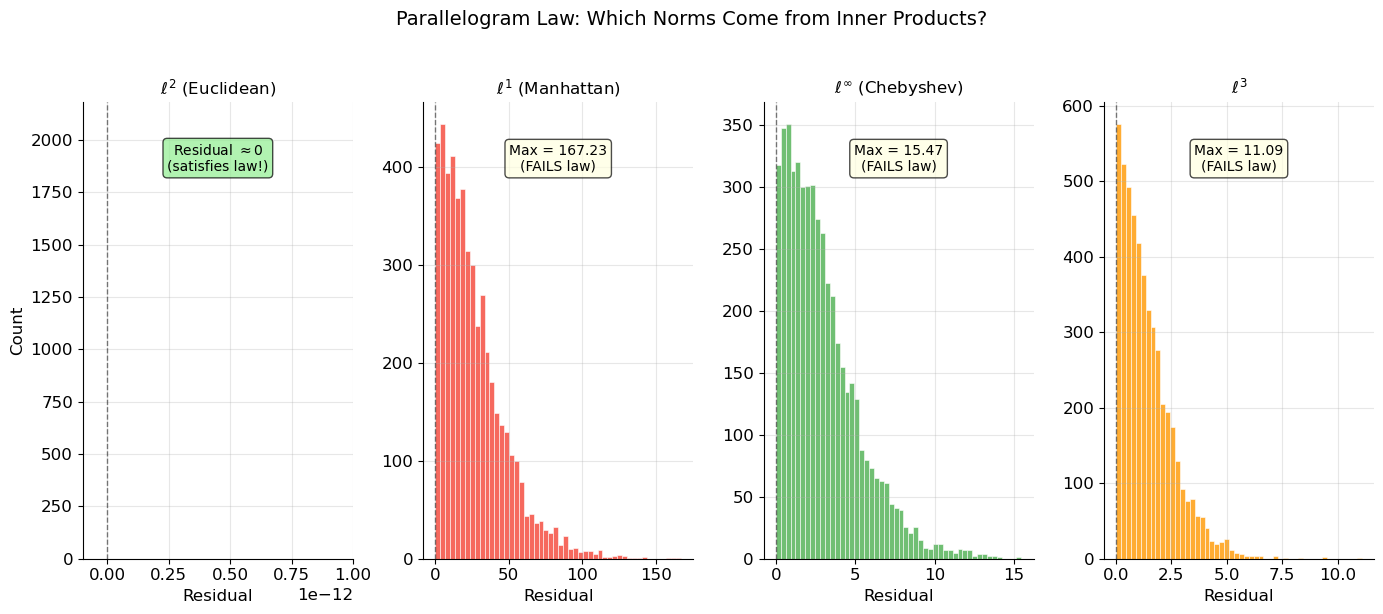

In [4]:
# Visualize the residual distributions
fig, axes = plt.subplots(1, 4, figsize=FIGSIZE_WIDE, sharey=False)

for ax, (name, res), color in zip(axes, results.items(), PALETTE):
    ax.hist(res, bins=50, color=color, alpha=0.8, edgecolor='white', linewidth=0.5)
    ax.set_title(name, fontsize=12)
    ax.set_xlabel('Residual')
    ax.axvline(x=0, color='black', linestyle='--', linewidth=1, alpha=0.5)
    if res.max() < 1e-10:
        ax.set_xlim(-1e-13, 1e-12)
        ax.text(0.5, 0.85, 'Residual $\\approx 0$\n(satisfies law!)',
                transform=ax.transAxes, ha='center', fontsize=10,
                bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.7))
    else:
        ax.text(0.5, 0.85, f'Max = {res.max():.2f}\n(FAILS law)',
                transform=ax.transAxes, ha='center', fontsize=10,
                bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.7))

axes[0].set_ylabel('Count')
fig.suptitle('Parallelogram Law: Which Norms Come from Inner Products?', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

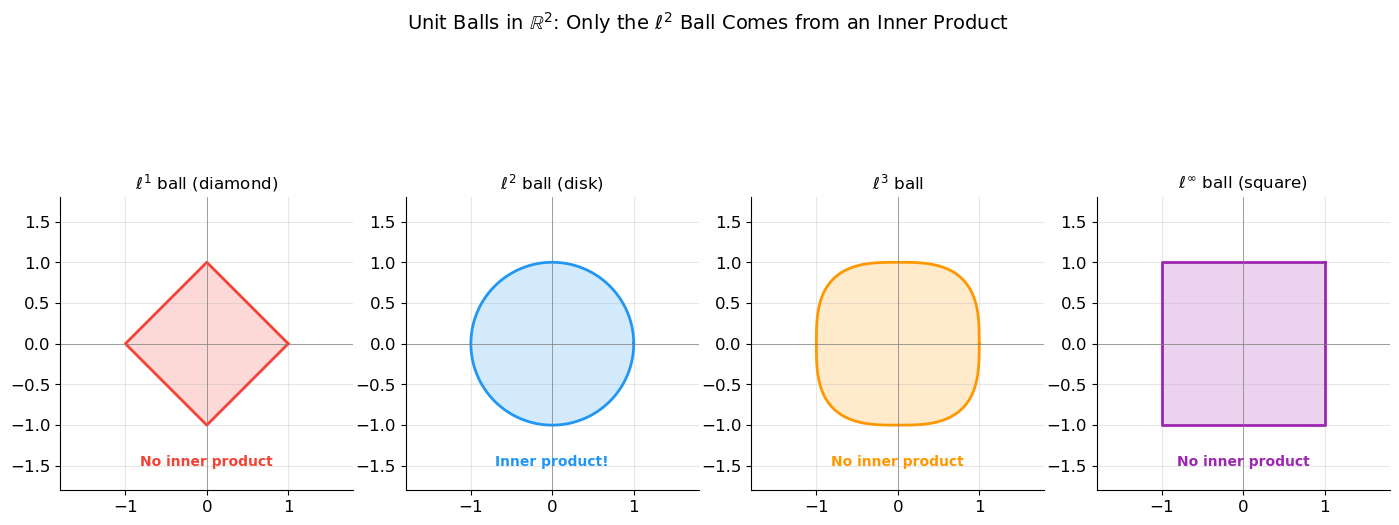

In [5]:
# Geometric visualization: unit balls in R^2 for different norms
# Only the l^2 ball is "round" (comes from an inner product)

theta = np.linspace(0, 2 * np.pi, 1000)

fig, axes = plt.subplots(1, 4, figsize=FIGSIZE_WIDE)

norm_info = [
    (r'$\ell^1$: $|x|+|y|=1$', lambda t: (np.sign(np.cos(t))*np.abs(np.cos(t)),
                                            np.sign(np.sin(t))*np.abs(np.sin(t))),
     False, C_RED),
    (r'$\ell^2$: $\sqrt{x^2+y^2}=1$', lambda t: (np.cos(t), np.sin(t)),
     True, C_BLUE),
    (r'$\ell^3$', None, False, C_ORANGE),
    (r'$\ell^\infty$: $\max(|x|,|y|)=1$', None, False, C_PURPLE),
]

# l^1 unit ball
ax = axes[0]
verts = np.array([[1,0],[0,1],[-1,0],[0,-1],[1,0]])
ax.fill(verts[:,0], verts[:,1], alpha=0.2, color=C_RED)
ax.plot(verts[:,0], verts[:,1], color=C_RED, linewidth=2)
ax.set_title(r'$\ell^1$ ball (diamond)', fontsize=12)
ax.text(0, -1.5, 'No inner product', ha='center', fontsize=10, color=C_RED, fontweight='bold')

# l^2 unit ball
ax = axes[1]
ax.fill(np.cos(theta), np.sin(theta), alpha=0.2, color=C_BLUE)
ax.plot(np.cos(theta), np.sin(theta), color=C_BLUE, linewidth=2)
ax.set_title(r'$\ell^2$ ball (disk)', fontsize=12)
ax.text(0, -1.5, 'Inner product!', ha='center', fontsize=10, color=C_BLUE, fontweight='bold')

# l^3 unit ball
ax = axes[2]
p = 3
r_p = (np.abs(np.cos(theta))**p + np.abs(np.sin(theta))**p)**(-1.0/p)
x_p = r_p * np.cos(theta)
y_p = r_p * np.sin(theta)
ax.fill(x_p, y_p, alpha=0.2, color=C_ORANGE)
ax.plot(x_p, y_p, color=C_ORANGE, linewidth=2)
ax.set_title(r'$\ell^3$ ball', fontsize=12)
ax.text(0, -1.5, 'No inner product', ha='center', fontsize=10, color=C_ORANGE, fontweight='bold')

# l^inf unit ball
ax = axes[3]
verts_inf = np.array([[1,1],[1,-1],[-1,-1],[-1,1],[1,1]])
ax.fill(verts_inf[:,0], verts_inf[:,1], alpha=0.2, color=C_PURPLE)
ax.plot(verts_inf[:,0], verts_inf[:,1], color=C_PURPLE, linewidth=2)
ax.set_title(r'$\ell^\infty$ ball (square)', fontsize=12)
ax.text(0, -1.5, 'No inner product', ha='center', fontsize=10, color=C_PURPLE, fontweight='bold')

for ax in axes:
    ax.set_xlim(-1.8, 1.8)
    ax.set_ylim(-1.8, 1.8)
    ax.set_aspect('equal')
    ax.axhline(0, color='grey', linewidth=0.5)
    ax.axvline(0, color='grey', linewidth=0.5)

fig.suptitle('Unit Balls in $\\mathbb{R}^2$: Only the $\\ell^2$ Ball Comes from an Inner Product',
             fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

**Key takeaway:** The $\ell^2$ norm has zero parallelogram residual (up to machine precision), confirming it arises from the standard inner product $\langle x, y \rangle = \sum_i x_i y_i$. The $\ell^1$, $\ell^3$, and $\ell^\infty$ norms have substantial non-zero residuals, proving they cannot come from any inner product. Geometrically, only the $\ell^2$ unit ball is an ellipsoid; the other unit balls have corners or different curvatures that violate the parallelogram law.

---

## 2. Hilbert Spaces

### 2.1 Definition

A **Hilbert space** is an inner product space that is **complete** with respect to the norm induced by its inner product. That is, every Cauchy sequence converges within the space.

$$H \text{ is a Hilbert space} \iff H \text{ is an inner product space AND } H \text{ is complete}$$

Recall that a Banach space is a complete normed space. So:

$$\text{Hilbert space} \subset \text{Banach space} \subset \text{normed space} \subset \text{metric space}$$

Every Hilbert space is a Banach space, but not every Banach space is a Hilbert space. The distinction is precisely the parallelogram law: a Banach space is a Hilbert space if and only if its norm satisfies the parallelogram law.

### 2.2 Key Examples

| Space | Elements | Inner Product | Why Complete? |
|-------|----------|--------------|---------------|
| $\mathbb{R}^n$ | Vectors $(x_1, \ldots, x_n)$ | $\langle x, y \rangle = \sum_{i=1}^n x_i y_i$ | Finite-dimensional: all norms are equivalent, completeness from $\mathbb{R}$ |
| $\ell^2$ | Sequences $(x_n)$ with $\sum |x_n|^2 < \infty$ | $\langle x, y \rangle = \sum_{n=1}^\infty x_n y_n$ | Riesz-Fischer theorem: $\ell^2$ is complete |
| $L^2[a,b]$ | Square-integrable functions | $\langle f, g \rangle = \int_a^b f(x)\overline{g(x)}\,dx$ | Riesz-Fischer: $L^p$ spaces are complete for $p \geq 1$ |

### 2.3 Non-Examples

- $C[0,1]$ with the $L^2$ inner product is an inner product space but **not** a Hilbert space. Continuous functions can have $L^2$-Cauchy sequences that converge to discontinuous functions (which are not in $C[0,1]$).
- The space of polynomials on $[0,1]$ with the $L^2$ inner product is incomplete: the Weierstrass approximation theorem guarantees polynomials are dense in $C[0,1]$, but they don't contain all their limit points.

### 2.4 Connection to Banach Spaces

The hierarchy of spaces:

$$\boxed{\text{Inner Product Space}} \xrightarrow{\text{+ completeness}} \boxed{\text{Hilbert Space}} \subset \boxed{\text{Banach Space}} \xrightarrow{\text{+ parallelogram law}} \boxed{\text{Hilbert Space}}$$

Important facts:
- $L^p[a,b]$ is a Banach space for all $1 \leq p \leq \infty$, but a Hilbert space **only** for $p=2$.
- $\ell^p$ is a Banach space for all $1 \leq p \leq \infty$, but a Hilbert space **only** for $p=2$.
- Every finite-dimensional inner product space is automatically a Hilbert space.

---

## 3. Orthogonality & Orthonormal Bases

### 3.1 Orthogonality

Two elements $x, y \in H$ are **orthogonal** (written $x \perp y$) if $\langle x, y \rangle = 0$.

The **orthogonal complement** of a subset $S \subseteq H$ is:

$$S^\perp = \{x \in H : \langle x, s \rangle = 0 \text{ for all } s \in S\}$$

Key properties:
- $S^\perp$ is always a closed subspace of $H$
- $S \cap S^\perp = \{0\}$
- If $M$ is a closed subspace, then $H = M \oplus M^\perp$ (orthogonal direct sum)

### 3.2 Orthonormal Systems

A set $\{e_n\}_{n \in I}$ is an **orthonormal system** (ONS) if:

$$\langle e_m, e_n \rangle = \delta_{mn} = \begin{cases} 1 & m = n \\ 0 & m \neq n \end{cases}$$

An ONS is an **orthonormal basis** (ONB, or complete orthonormal system) if its span is dense in $H$:

$$\overline{\text{span}\{e_n\}} = H$$

### 3.3 Gram-Schmidt Process

Given a linearly independent set $\{v_1, v_2, \ldots\}$, the Gram-Schmidt process produces an orthonormal set $\{e_1, e_2, \ldots\}$:

$$\tilde{e}_k = v_k - \sum_{j=1}^{k-1} \langle v_k, e_j \rangle \, e_j, \qquad e_k = \frac{\tilde{e}_k}{\|\tilde{e}_k\|}$$

This works in **any** inner product space, including function spaces with the $L^2$ inner product.

### 3.4 Bessel's Inequality (Preview)

For any orthonormal system $\{e_n\}$ and any $x \in H$:

$$\sum_{n=1}^\infty |\langle x, e_n \rangle|^2 \leq \|x\|^2$$

The coefficients $\langle x, e_n \rangle$ are the **Fourier coefficients** of $x$ with respect to the ONS. We will return to this in Section 6.

### Implementation: Gram-Schmidt on Function Spaces — Deriving Legendre Polynomials

We apply Gram-Schmidt to the monomials $\{1, x, x^2, x^3, \ldots\}$ on the interval $[-1, 1]$ with the $L^2$ inner product:

$$\langle f, g \rangle = \int_{-1}^{1} f(x)\,g(x)\,dx$$

The result is the **Legendre polynomials** $\{P_0, P_1, P_2, \ldots\}$, one of the most important orthogonal polynomial families in mathematics and physics.

In [6]:
def l2_inner_product(f_vals, g_vals, x):
    """Compute L^2 inner product <f, g> = integral of f*g over the grid x
    using the trapezoidal rule."""
    return np.trapezoid(f_vals * g_vals, x)


def l2_norm(f_vals, x):
    """Compute L^2 norm ||f|| = sqrt(<f, f>)."""
    return np.sqrt(l2_inner_product(f_vals, f_vals, x))


def gram_schmidt_functions(monomial_fns, x):
    """Apply Gram-Schmidt to a list of functions evaluated on grid x.
    
    Parameters
    ----------
    monomial_fns : list of arrays, each shape (len(x),)
        The input functions to orthogonalize (e.g., monomials)
    x : array
        The quadrature grid
    
    Returns
    -------
    ortho : list of arrays
        Orthonormalized functions
    steps : list of dicts
        Intermediate computation details for visualization
    """
    ortho = []
    steps = []
    
    for k, v_k in enumerate(monomial_fns):
        # Subtract projections onto all previous orthonormal vectors
        u_k = v_k.copy()
        projections = []
        for j, e_j in enumerate(ortho):
            coeff = l2_inner_product(v_k, e_j, x)
            u_k = u_k - coeff * e_j
            projections.append((j, coeff))
        
        # Normalize
        norm_u = l2_norm(u_k, x)
        e_k = u_k / norm_u
        ortho.append(e_k)
        
        steps.append({
            'k': k,
            'input': v_k.copy(),
            'unnormalized': u_k.copy(),
            'normalized': e_k.copy(),
            'norm_before': norm_u,
            'projections': projections,
        })
    
    return ortho, steps


# Set up the computation
x = np.linspace(-1, 1, 2000)
n_polys = 6  # Produce P_0 through P_5

# Monomials: 1, x, x^2, ..., x^(n-1)
monomials = [x**k for k in range(n_polys)]

# Apply Gram-Schmidt
ortho_fns, gs_steps = gram_schmidt_functions(monomials, x)

# Verify orthonormality: compute the Gram matrix <e_i, e_j>
gram_matrix = np.zeros((n_polys, n_polys))
for i in range(n_polys):
    for j in range(n_polys):
        gram_matrix[i, j] = l2_inner_product(ortho_fns[i], ortho_fns[j], x)

print("Gram matrix (should be identity):")
print(np.round(gram_matrix, 10))

Gram matrix (should be identity):
[[ 1.  0.  0. -0. -0.  0.]
 [ 0.  1. -0. -0.  0.  0.]
 [ 0. -0.  1.  0. -0. -0.]
 [-0. -0.  0.  1. -0.  0.]
 [-0.  0. -0. -0.  1. -0.]
 [ 0.  0. -0.  0. -0.  1.]]


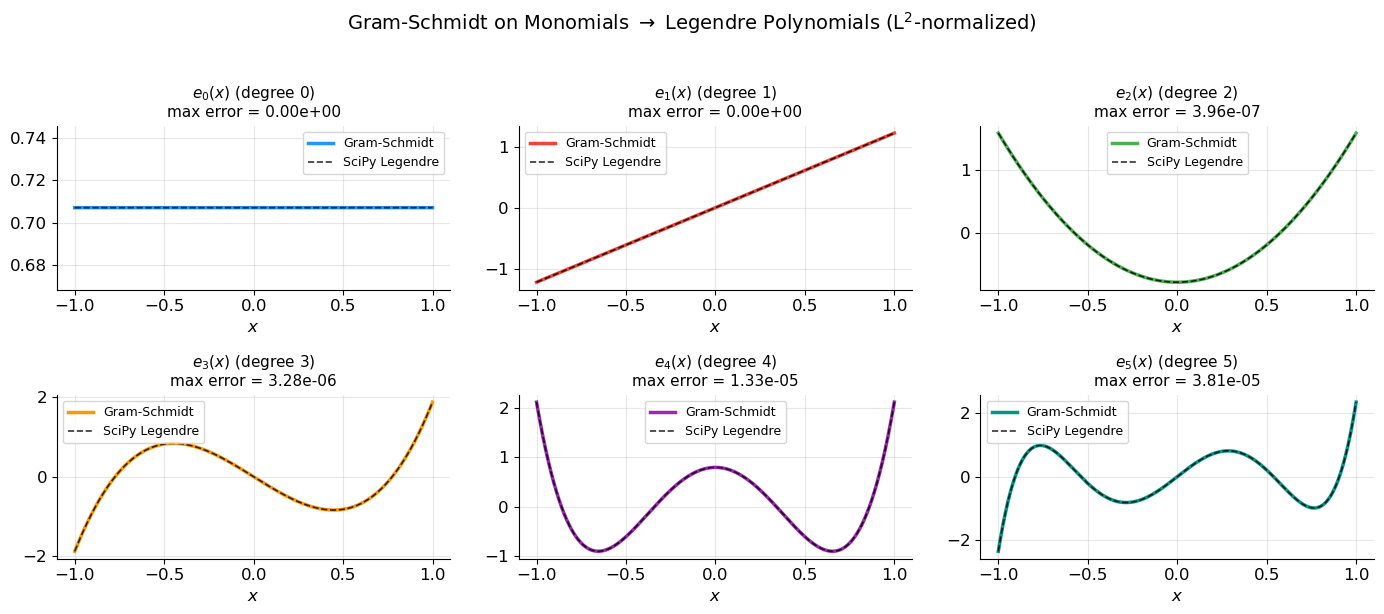

In [7]:
# Compare our Gram-Schmidt results to the standard Legendre polynomials
# (SciPy's legendre gives the standard normalization P_n(1)=1, not L^2-normalized)

fig, axes = plt.subplots(2, 3, figsize=FIGSIZE_WIDE)
axes = axes.ravel()

for k in range(n_polys):
    ax = axes[k]
    
    # Our Gram-Schmidt result (L^2 normalized)
    our_poly = ortho_fns[k]
    
    # Standard Legendre polynomial (normalize to match L^2 convention)
    # The L^2 norm of P_n on [-1,1] is sqrt(2/(2n+1))
    P_n = legendre(k)(x)
    P_n_normalized = P_n / l2_norm(P_n, x)
    
    # Ensure sign convention matches (our result may differ by a sign)
    if np.sign(our_poly[-1]) != np.sign(P_n_normalized[-1]):
        P_n_normalized = -P_n_normalized
    
    ax.plot(x, our_poly, color=PALETTE[k], linewidth=2.5, label='Gram-Schmidt')
    ax.plot(x, P_n_normalized, color='black', linewidth=1.2, linestyle='--',
            label='SciPy Legendre', alpha=0.8)
    
    max_err = np.max(np.abs(our_poly - P_n_normalized))
    ax.set_title(f'$e_{k}(x)$ (degree {k})\nmax error = {max_err:.2e}', fontsize=11)
    ax.set_xlabel('$x$')
    ax.legend(fontsize=9, loc='best')

fig.suptitle('Gram-Schmidt on Monomials $\\rightarrow$ Legendre Polynomials (L$^2$-normalized)',
             fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

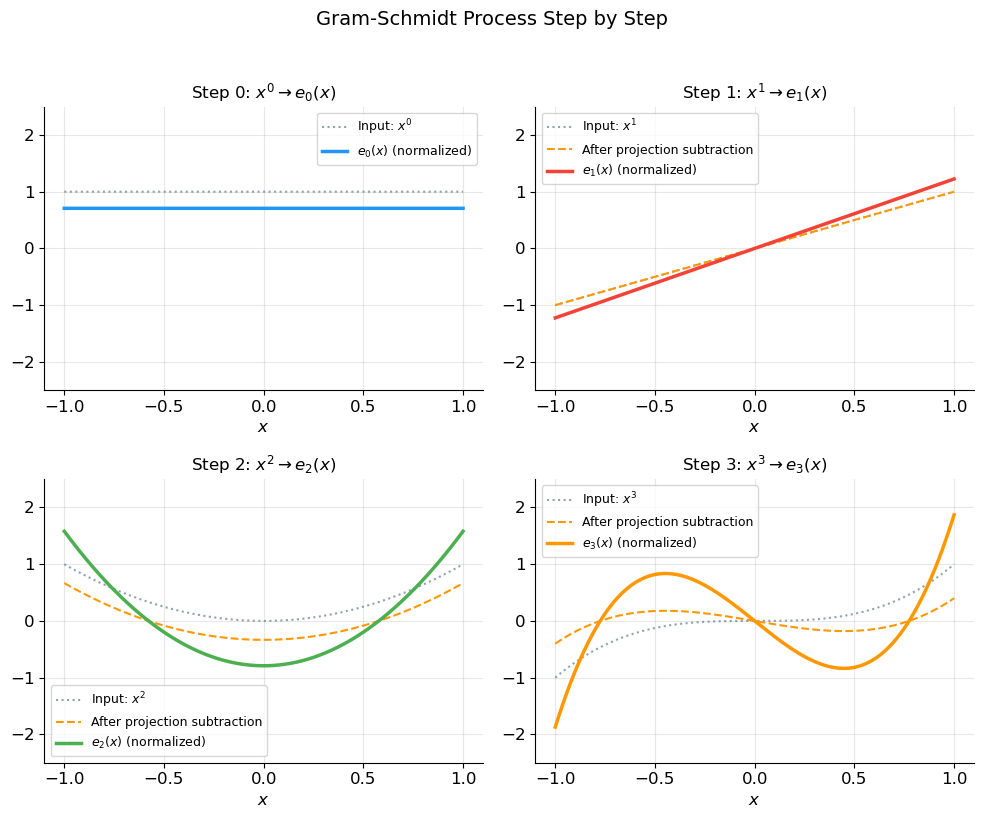

In [8]:
# Visualize each step of the Gram-Schmidt process for the first 4 polynomials
fig, axes = plt.subplots(2, 2, figsize=FIGSIZE_TALL)
axes = axes.ravel()

for idx in range(4):
    ax = axes[idx]
    step = gs_steps[idx]
    k = step['k']
    
    # Plot the input monomial
    ax.plot(x, step['input'], color=C_GREY, linewidth=1.5, linestyle=':',
            label=f'Input: $x^{k}$', alpha=0.7)
    
    # Plot the unnormalized result (after subtracting projections)
    if k > 0:
        ax.plot(x, step['unnormalized'], color=C_ORANGE, linewidth=1.5, linestyle='--',
                label='After projection subtraction')
    
    # Plot the final normalized result
    ax.plot(x, step['normalized'], color=PALETTE[k], linewidth=2.5,
            label=f'$e_{k}(x)$ (normalized)')
    
    ax.set_title(f'Step {k}: $x^{k} \\to e_{k}(x)$', fontsize=12)
    ax.set_xlabel('$x$')
    ax.legend(fontsize=9)
    ax.set_ylim(-2.5, 2.5)

fig.suptitle('Gram-Schmidt Process Step by Step', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

**Observation:** Starting from the monomials $\{1, x, x^2, x^3, \ldots\}$ and applying Gram-Schmidt with the $L^2[-1,1]$ inner product, we recover the (normalized) Legendre polynomials. Each step subtracts the projections onto all previously computed orthonormal polynomials, then normalizes. The Gram matrix confirms perfect orthonormality (identity matrix up to numerical precision).

---

## 4. Projection Theorem & Best Approximation

### 4.1 The Projection Theorem

**Theorem.** Let $M$ be a **closed subspace** of a Hilbert space $H$. For every $x \in H$, there exists a unique $m_0 \in M$ such that:

$$\|x - m_0\| = \inf_{m \in M} \|x - m\|$$

Moreover, $m_0$ is characterized by the condition:

$$(x - m_0) \perp M \quad \iff \quad \langle x - m_0, m \rangle = 0 \quad \forall m \in M$$

The map $P_M : H \to M$ defined by $P_M(x) = m_0$ is called the **orthogonal projection** onto $M$.

**Proof sketch.** Let $d = \inf_{m \in M} \|x - m\|$ and take a minimizing sequence $(m_n)$ with $\|x - m_n\| \to d$. The parallelogram law applied to $x - m_n$ and $x - m_k$ shows that $(m_n)$ is Cauchy:

$$\|m_n - m_k\|^2 = 2\|x - m_n\|^2 + 2\|x - m_k\|^2 - 4\left\|x - \frac{m_n + m_k}{2}\right\|^2 \leq 2\|x - m_n\|^2 + 2\|x - m_k\|^2 - 4d^2 \to 0$$

By completeness, $m_n \to m_0 \in M$. Uniqueness and the orthogonality condition follow from the strict convexity of the norm. $\blacksquare$

### 4.2 Projection Formula

If $\{e_1, e_2, \ldots, e_n\}$ (or $\{e_1, e_2, \ldots\}$ in the infinite case) is an ONB for $M$, then:

$$P_M(x) = \sum_k \langle x, e_k \rangle \, e_k$$

Each coefficient $\langle x, e_k \rangle$ is the **Fourier coefficient** of $x$ with respect to $e_k$.

### 4.3 Fourier Series as Orthogonal Projection

The Fourier series of a function $f \in L^2[-\pi, \pi]$ is precisely the orthogonal projection onto the subspace spanned by $\{e^{inx}/\sqrt{2\pi}\}_{n \in \mathbb{Z}}$. In the real formulation:

$$f(x) \approx \frac{a_0}{2} + \sum_{n=1}^{N} \left[a_n \cos(nx) + b_n \sin(nx)\right]$$

where $a_n = \frac{1}{\pi}\int_{-\pi}^{\pi} f(x)\cos(nx)\,dx$ and $b_n = \frac{1}{\pi}\int_{-\pi}^{\pi} f(x)\sin(nx)\,dx$.

The partial sum $S_N f$ is the **best approximation** to $f$ in the $L^2$ norm among all trigonometric polynomials of degree $\leq N$. No other combination of sines and cosines (up to degree $N$) can get closer to $f$ in the $L^2$ sense.

### Implementation: Fourier Series Approximation and Error Decay

We compute Fourier coefficients as inner products and observe convergence of partial sums for different target functions.

In [9]:
def fourier_coefficients(f_vals, x, N):
    """Compute Fourier coefficients a_0, a_1,...,a_N, b_1,...,b_N
    for a function f on [-pi, pi] using inner products.
    
    a_n = (1/pi) * integral f(x) cos(nx) dx
    b_n = (1/pi) * integral f(x) sin(nx) dx
    """
    a = np.zeros(N + 1)
    b = np.zeros(N + 1)  # b[0] is unused (always 0)
    
    for n in range(N + 1):
        a[n] = (1.0 / np.pi) * np.trapezoid(f_vals * np.cos(n * x), x)
        if n > 0:
            b[n] = (1.0 / np.pi) * np.trapezoid(f_vals * np.sin(n * x), x)
    
    return a, b


def fourier_partial_sum(a, b, x, N):
    """Evaluate the Fourier partial sum S_N(x) = a0/2 + sum_{n=1}^N [a_n cos(nx) + b_n sin(nx)]."""
    result = np.full_like(x, a[0] / 2.0)
    for n in range(1, N + 1):
        result += a[n] * np.cos(n * x) + b[n] * np.sin(n * x)
    return result


# Define target functions on [-pi, pi]
x_fourier = np.linspace(-np.pi, np.pi, 4000)

# Square wave
square_wave = np.sign(x_fourier)

# Sawtooth wave
sawtooth = x_fourier / np.pi

# Triangle wave
triangle = 1 - 2 * np.abs(x_fourier) / np.pi

functions = {
    'Square Wave': square_wave,
    'Sawtooth Wave': sawtooth,
    'Triangle Wave': triangle,
}

N_max = 50
N_terms_to_plot = [1, 3, 7, 20]

# Compute all Fourier coefficients
all_coeffs = {}
for name, f_vals in functions.items():
    a, b = fourier_coefficients(f_vals, x_fourier, N_max)
    all_coeffs[name] = (a, b)

print("Square wave Fourier coefficients (first few):")
a_sq, b_sq = all_coeffs['Square Wave']
print(f"  a_0 = {a_sq[0]:.6f}  (should be ~0)")
for n in range(1, 8):
    print(f"  a_{n} = {a_sq[n]:.6f}, b_{n} = {b_sq[n]:.6f}")
print("\n(For odd n: b_n = 4/(n*pi); for even n: b_n = 0)")

Square wave Fourier coefficients (first few):
  a_0 = 0.000000  (should be ~0)
  a_1 = -0.000000, b_1 = 1.273239
  a_2 = 0.000000, b_2 = 0.000000
  a_3 = 0.000000, b_3 = 0.424413
  a_4 = -0.000000, b_4 = 0.000001
  a_5 = 0.000000, b_5 = 0.254648
  a_6 = 0.000000, b_6 = 0.000001
  a_7 = 0.000000, b_7 = 0.181891

(For odd n: b_n = 4/(n*pi); for even n: b_n = 0)


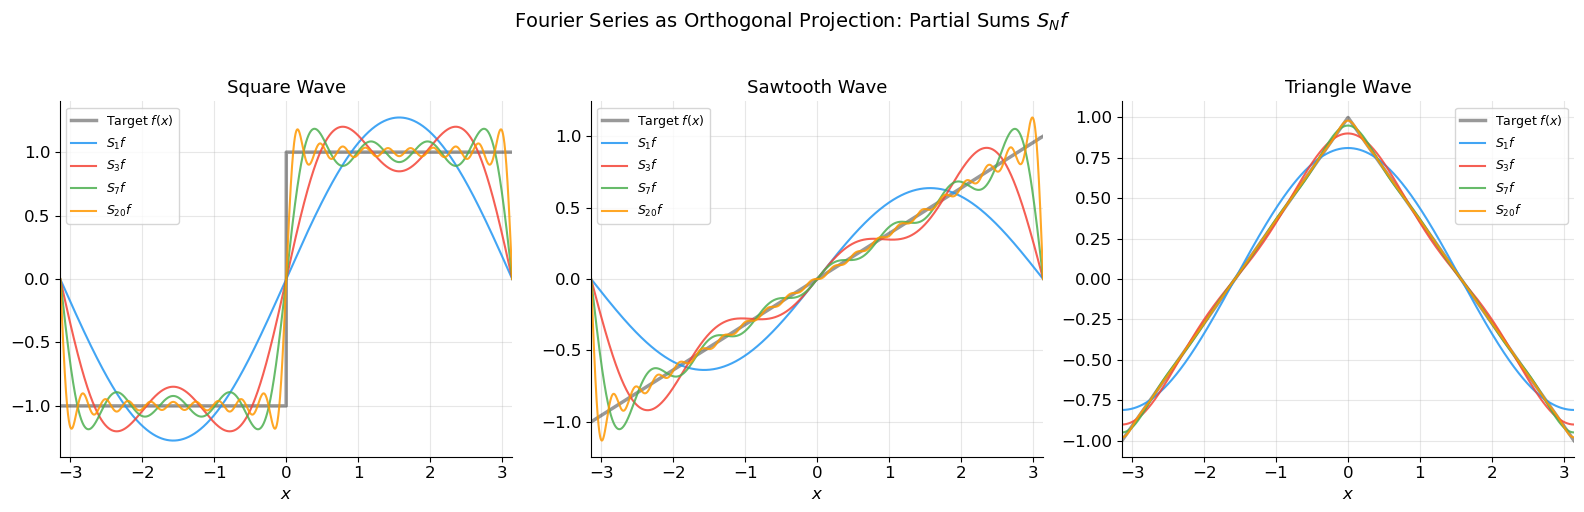

In [10]:
# Plot Fourier partial sums converging to each target function
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, (name, f_vals) in zip(axes, functions.items()):
    a, b = all_coeffs[name]
    
    ax.plot(x_fourier, f_vals, color='black', linewidth=2.5, alpha=0.4, label='Target $f(x)$')
    
    for i, N in enumerate(N_terms_to_plot):
        S_N = fourier_partial_sum(a, b, x_fourier, N)
        ax.plot(x_fourier, S_N, color=PALETTE[i], linewidth=1.5,
                label=f'$S_{{{N}}}f$', alpha=0.85)
    
    ax.set_title(name, fontsize=13)
    ax.set_xlabel('$x$')
    ax.legend(fontsize=9, loc='best')
    ax.set_xlim(-np.pi, np.pi)

fig.suptitle('Fourier Series as Orthogonal Projection: Partial Sums $S_N f$',
             fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

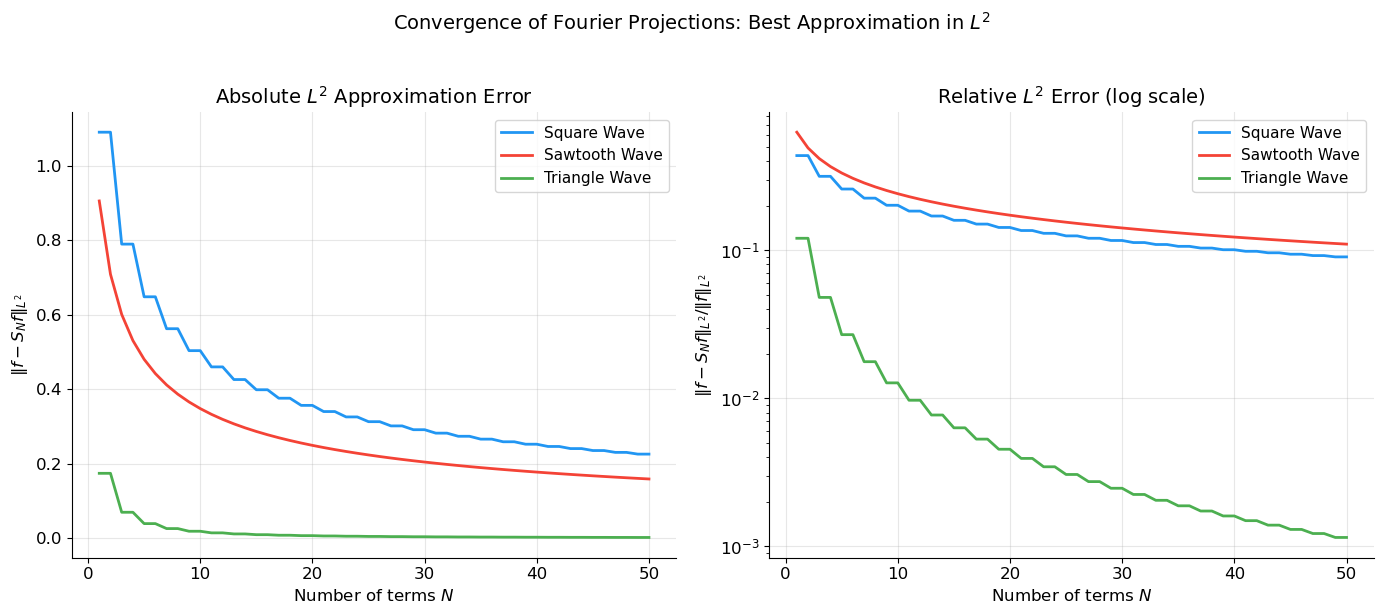

In [11]:
# L^2 approximation error vs number of terms
# This demonstrates the projection theorem: S_N is the BEST approximation

N_range = np.arange(1, N_max + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=FIGSIZE_WIDE)

for idx, (name, f_vals) in enumerate(functions.items()):
    a, b = all_coeffs[name]
    
    # Compute L^2 norm of target
    f_norm_sq = np.trapezoid(f_vals**2, x_fourier)
    
    errors = []
    relative_errors = []
    for N in N_range:
        S_N = fourier_partial_sum(a, b, x_fourier, N)
        err_sq = np.trapezoid((f_vals - S_N)**2, x_fourier)
        errors.append(np.sqrt(err_sq))
        relative_errors.append(np.sqrt(err_sq / f_norm_sq))
    
    ax1.plot(N_range, errors, color=PALETTE[idx], linewidth=2, label=name)
    ax2.semilogy(N_range, relative_errors, color=PALETTE[idx], linewidth=2, label=name)

ax1.set_xlabel('Number of terms $N$')
ax1.set_ylabel(r'$\|f - S_N f\|_{L^2}$')
ax1.set_title('Absolute $L^2$ Approximation Error')
ax1.legend()

ax2.set_xlabel('Number of terms $N$')
ax2.set_ylabel(r'$\|f - S_N f\|_{L^2} / \|f\|_{L^2}$')
ax2.set_title('Relative $L^2$ Error (log scale)')
ax2.legend()

fig.suptitle('Convergence of Fourier Projections: Best Approximation in $L^2$',
             fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

**Key observations:**

1. The Fourier partial sums converge to the target functions in the $L^2$ norm, as guaranteed by the projection theorem.
2. **Smooth functions converge faster**: The triangle wave (continuous, piecewise-linear) converges much faster than the square wave (discontinuous). This reflects the general principle that smoother functions have faster-decaying Fourier coefficients.
3. The **Gibbs phenomenon** (overshoot near discontinuities) is visible for the square and sawtooth waves. This is a pointwise phenomenon; the $L^2$ error still decreases monotonically.
4. Each partial sum $S_N f$ is the **optimal** projection onto $\text{span}\{1, \cos x, \sin x, \ldots, \cos Nx, \sin Nx\}$.

---

## 5. Riesz Representation Theorem

### 5.1 Statement

**Theorem (Riesz-Frechet).** Let $H$ be a Hilbert space and $\varphi : H \to \mathbb{F}$ a **continuous linear functional** (i.e., $\varphi \in H^*$). Then there exists a **unique** $y \in H$ such that:

$$\varphi(x) = \langle x, y \rangle \quad \text{for all } x \in H$$

Moreover, $\|\varphi\|_{H^*} = \|y\|_H$.

### 5.2 Proof

**Case 1: $\varphi = 0$.** Take $y = 0$. Done.

**Case 2: $\varphi \neq 0$.** Let $M = \ker(\varphi) = \{x \in H : \varphi(x) = 0\}$.

Since $\varphi$ is continuous and linear, $M$ is a closed subspace of $H$, and $M \neq H$ (because $\varphi \neq 0$).

Therefore $M^\perp \neq \{0\}$: there exists $z \in M^\perp$ with $z \neq 0$ and $\varphi(z) \neq 0$.

For any $x \in H$, we can write:
$$x = \underbrace{\left(x - \frac{\varphi(x)}{\varphi(z)}z\right)}_{\in \ker(\varphi) = M} + \frac{\varphi(x)}{\varphi(z)}z$$

Now set $y = \frac{\overline{\varphi(z)}}{\|z\|^2} z$. Then:

$$\langle x, y \rangle = \left\langle x, \frac{\overline{\varphi(z)}}{\|z\|^2} z \right\rangle = \frac{\varphi(z)}{\|z\|^2} \langle x, z \rangle$$

Since $x - \frac{\varphi(x)}{\varphi(z)}z \in M$ and $z \in M^\perp$:

$$\langle x, z \rangle = \frac{\varphi(x)}{\varphi(z)} \langle z, z \rangle = \frac{\varphi(x)}{\varphi(z)} \|z\|^2$$

So $\langle x, y \rangle = \frac{\varphi(z)}{\|z\|^2} \cdot \frac{\varphi(x)}{\varphi(z)} \|z\|^2 = \varphi(x)$. $\blacksquare$

**Uniqueness:** If $\langle x, y_1 \rangle = \langle x, y_2 \rangle$ for all $x$, then $\langle x, y_1 - y_2 \rangle = 0$ for all $x$; taking $x = y_1 - y_2$ gives $\|y_1 - y_2\|^2 = 0$.

### 5.3 Significance: $H \cong H^*$

The Riesz Representation Theorem establishes a **conjugate-linear isometric isomorphism** between $H$ and its dual $H^*$:

$$\Phi : H \to H^*, \quad \Phi(y) = \langle \cdot, y \rangle$$

This is profound:
- In a Hilbert space, **every continuous linear functional is representable as an inner product**.
- The dual space $H^*$ has no "extra" structure beyond what $H$ already provides.
- This fails for general Banach spaces (e.g., $(\ell^1)^* = \ell^\infty \neq \ell^1$).

### 5.4 Concrete Examples

**Example 1: $\ell^2$.** Consider the functional $\varphi : \ell^2 \to \mathbb{R}$ defined by:

$$\varphi(x) = 3x_1 + 2x_2 - x_3$$

By Riesz, $\varphi(x) = \langle x, y \rangle$ where $y = (3, 2, -1, 0, 0, \ldots) \in \ell^2$.

And $\|\varphi\|_{(\ell^2)^*} = \|y\|_{\ell^2} = \sqrt{9+4+1} = \sqrt{14}$.

**Example 2: $L^2[0,1]$.** Consider the functional:

$$\varphi(f) = \int_0^1 f(x) \cdot e^x \, dx$$

By Riesz, $\varphi(f) = \langle f, g \rangle$ where $g(x) = e^x \in L^2[0,1]$.

And $\|\varphi\| = \|g\|_{L^2} = \left(\int_0^1 e^{2x}\,dx\right)^{1/2} = \left(\frac{e^2 - 1}{2}\right)^{1/2}$.

In [12]:
# Riesz Representation Theorem: Numerical Illustration

# Example 1: ell^2
print("=" * 60)
print("Example 1: Riesz representation in ell^2")
print("=" * 60)

# Functional: phi(x) = 3*x_1 + 2*x_2 - x_3
y_riesz = np.array([3.0, 2.0, -1.0, 0.0, 0.0])  # Riesz representer

# Test on several vectors
test_vectors = [
    np.array([1.0, 0.0, 0.0, 0.0, 0.0]),
    np.array([0.0, 1.0, 0.0, 0.0, 0.0]),
    np.array([1.0, 1.0, 1.0, 0.0, 0.0]),
    np.array([2.0, -1.0, 3.0, 5.0, -2.0]),
]

for x_test in test_vectors:
    phi_x = 3*x_test[0] + 2*x_test[1] - x_test[2]  # Direct evaluation
    inner = np.dot(x_test, y_riesz)                  # Via inner product
    print(f"  x = {x_test}, phi(x) = {phi_x:.4f}, <x,y> = {inner:.4f}, match = {np.isclose(phi_x, inner)}")

print(f"\n  ||phi|| = ||y|| = sqrt(14) = {np.sqrt(14):.6f}")
print(f"  ||y||_ell2 = {np.linalg.norm(y_riesz):.6f}")

# Example 2: L^2[0,1]
print("\n" + "=" * 60)
print("Example 2: Riesz representation in L^2[0,1]")
print("=" * 60)

x_grid = np.linspace(0, 1, 5000)
g_riesz = np.exp(x_grid)  # Riesz representer g(x) = e^x

# Functional: phi(f) = integral_0^1 f(x) e^x dx
# Test on several functions
test_fns = {
    'f(x) = 1': np.ones_like(x_grid),
    'f(x) = x': x_grid,
    'f(x) = x^2': x_grid**2,
    'f(x) = sin(pi*x)': np.sin(np.pi * x_grid),
}

for name, f_vals in test_fns.items():
    phi_f = np.trapezoid(f_vals * np.exp(x_grid), x_grid)
    inner = np.trapezoid(f_vals * g_riesz, x_grid)
    print(f"  {name}: phi(f) = {phi_f:.6f}, <f,g> = {inner:.6f}, match = {np.isclose(phi_f, inner)}")

norm_exact = np.sqrt((np.exp(2) - 1) / 2)
norm_numerical = np.sqrt(np.trapezoid(g_riesz**2, x_grid))
print(f"\n  ||phi|| = ||g||_L2 (exact)     = {norm_exact:.6f}")
print(f"  ||g||_L2 (numerical) = {norm_numerical:.6f}")

Example 1: Riesz representation in ell^2
  x = [1. 0. 0. 0. 0.], phi(x) = 3.0000, <x,y> = 3.0000, match = True
  x = [0. 1. 0. 0. 0.], phi(x) = 2.0000, <x,y> = 2.0000, match = True
  x = [1. 1. 1. 0. 0.], phi(x) = 4.0000, <x,y> = 4.0000, match = True
  x = [ 2. -1.  3.  5. -2.], phi(x) = 1.0000, <x,y> = 1.0000, match = True

  ||phi|| = ||y|| = sqrt(14) = 3.741657
  ||y||_ell2 = 3.741657

Example 2: Riesz representation in L^2[0,1]
  f(x) = 1: phi(f) = 1.718282, <f,g> = 1.718282, match = True
  f(x) = x: phi(f) = 1.000000, <f,g> = 1.000000, match = True
  f(x) = x^2: phi(f) = 0.718282, <f,g> = 0.718282, match = True
  f(x) = sin(pi*x): phi(f) = 1.074678, <f,g> = 1.074678, match = True

  ||phi|| = ||g||_L2 (exact)     = 1.787324
  ||g||_L2 (numerical) = 1.787324


---

## 6. Bessel's Inequality & Parseval's Identity

### 6.1 Bessel's Inequality

**Theorem.** Let $\{e_n\}_{n=1}^\infty$ be an orthonormal system in a Hilbert space $H$, and let $x \in H$. Then:

$$\sum_{n=1}^\infty |\langle x, e_n \rangle|^2 \leq \|x\|^2$$

**Proof.** For any finite $N$, let $S_N = \sum_{n=1}^N \langle x, e_n \rangle \, e_n$. Then:

$$0 \leq \|x - S_N\|^2 = \|x\|^2 - 2\,\text{Re}\langle x, S_N\rangle + \|S_N\|^2 = \|x\|^2 - \sum_{n=1}^N |\langle x, e_n\rangle|^2$$

where we used the orthonormality to compute $\langle x, S_N \rangle = \sum_{n=1}^N |\langle x, e_n \rangle|^2 = \|S_N\|^2$. Rearranging:

$$\sum_{n=1}^N |\langle x, e_n\rangle|^2 \leq \|x\|^2$$

Taking $N \to \infty$ gives Bessel's inequality. $\blacksquare$

### 6.2 Parseval's Identity

**Theorem.** If $\{e_n\}$ is an **orthonormal basis** (complete ONS) for $H$, then Bessel's inequality becomes an **equality**:

$$\|x\|^2 = \sum_{n=1}^\infty |\langle x, e_n \rangle|^2 \qquad \text{(Parseval's identity)}$$

This is a deep result with a beautiful interpretation:

- **Energy conservation**: The total "energy" $\|x\|^2$ equals the sum of energies in each frequency component $|\langle x, e_n \rangle|^2$.
- **Isometric isomorphism**: The map $x \mapsto (\langle x, e_n \rangle)_{n=1}^\infty$ is an isometry from $H$ onto $\ell^2$. This means **every separable Hilbert space is isomorphic to $\ell^2$**.

Conversely, Parseval's identity **characterizes completeness**: an ONS is an ONB if and only if Parseval's identity holds for all $x \in H$.

### 6.3 Generalized Parseval for Two Elements

For an ONB $\{e_n\}$ and any $x, y \in H$:

$$\langle x, y \rangle = \sum_{n=1}^\infty \langle x, e_n \rangle \overline{\langle y, e_n \rangle}$$

This follows from applying Parseval's identity to $x + y$ and $x - y$ and using the polarization identity.

### Implementation: Parseval's Identity and Energy Spectrum

We verify Parseval's identity: compute $\|f\|^2$ directly and compare with $\sum |\langle f, e_n \rangle|^2$. We also visualize how a signal's energy distributes across frequency components.

In [13]:
def compute_fourier_energy(f_vals, x, N_max):
    """Compute Fourier coefficient energies and cumulative energy.
    
    Uses the ONB {1/sqrt(2pi), cos(nx)/sqrt(pi), sin(nx)/sqrt(pi)} for L^2[-pi, pi].
    
    Returns
    -------
    energies : array of shape (2*N_max + 1,)
        |<f, e_n>|^2 for each basis element
    cumulative : array
        Running sum of energies
    total_energy : float
        ||f||^2 computed directly via integration
    labels : list of str
        Labels for each energy component
    """
    # Direct computation of ||f||^2
    total_energy = np.trapezoid(f_vals**2, x)
    
    # Fourier coefficients with the L^2-normalized ONB
    # The orthonormal basis for L^2[-pi, pi] is:
    #   e_0 = 1/sqrt(2*pi)
    #   e_n^c = cos(nx)/sqrt(pi)  for n >= 1
    #   e_n^s = sin(nx)/sqrt(pi)  for n >= 1
    
    energies = []
    labels = []
    
    # n = 0: constant term
    c_0 = np.trapezoid(f_vals * (1.0 / np.sqrt(2 * np.pi)), x)
    energies.append(c_0**2)
    labels.append('$a_0$')
    
    # n >= 1: cosine and sine terms
    for n in range(1, N_max + 1):
        c_n = np.trapezoid(f_vals * np.cos(n * x) / np.sqrt(np.pi), x)
        s_n = np.trapezoid(f_vals * np.sin(n * x) / np.sqrt(np.pi), x)
        energies.append(c_n**2)
        energies.append(s_n**2)
        labels.append(f'$a_{{{n}}}$')
        labels.append(f'$b_{{{n}}}$')
    
    energies = np.array(energies)
    cumulative = np.cumsum(energies)
    
    return energies, cumulative, total_energy, labels


# Test functions
x_p = np.linspace(-np.pi, np.pi, 8000)

test_signals = {
    'Square wave': np.sign(x_p),
    'Sawtooth': x_p / np.pi,
    'Smooth: $\\cos(x) + 0.5\\sin(3x)$': np.cos(x_p) + 0.5*np.sin(3*x_p),
    'Gaussian pulse': np.exp(-2 * x_p**2),
}

N_max_parseval = 60

print("Parseval's Identity Verification: ||f||^2  vs  sum |<f, e_n>|^2")
print("=" * 70)

all_energy_data = {}
for name, f_vals in test_signals.items():
    energies, cumulative, total_energy, labels = compute_fourier_energy(f_vals, x_p, N_max_parseval)
    all_energy_data[name] = (energies, cumulative, total_energy, labels)
    
    parseval_sum = cumulative[-1]
    clean_name = name.replace('$', '').replace('\\', '')
    print(f"  {clean_name:<40s}  ||f||^2 = {total_energy:.6f}   sum = {parseval_sum:.6f}   "
          f"ratio = {parseval_sum/total_energy:.8f}")

Parseval's Identity Verification: ||f||^2  vs  sum |<f, e_n>|^2
  Square wave                               ||f||^2 = 6.283185   sum = 6.240744   ratio = 0.99324525
  Sawtooth                                  ||f||^2 = 2.094395   sum = 2.073342   ratio = 0.98994807
  Smooth: cos(x) + 0.5sin(3x)               ||f||^2 = 3.926991   sum = 3.926991   ratio = 1.00000000
  Gaussian pulse                            ||f||^2 = 0.886227   sum = 0.886227   ratio = 1.00000000


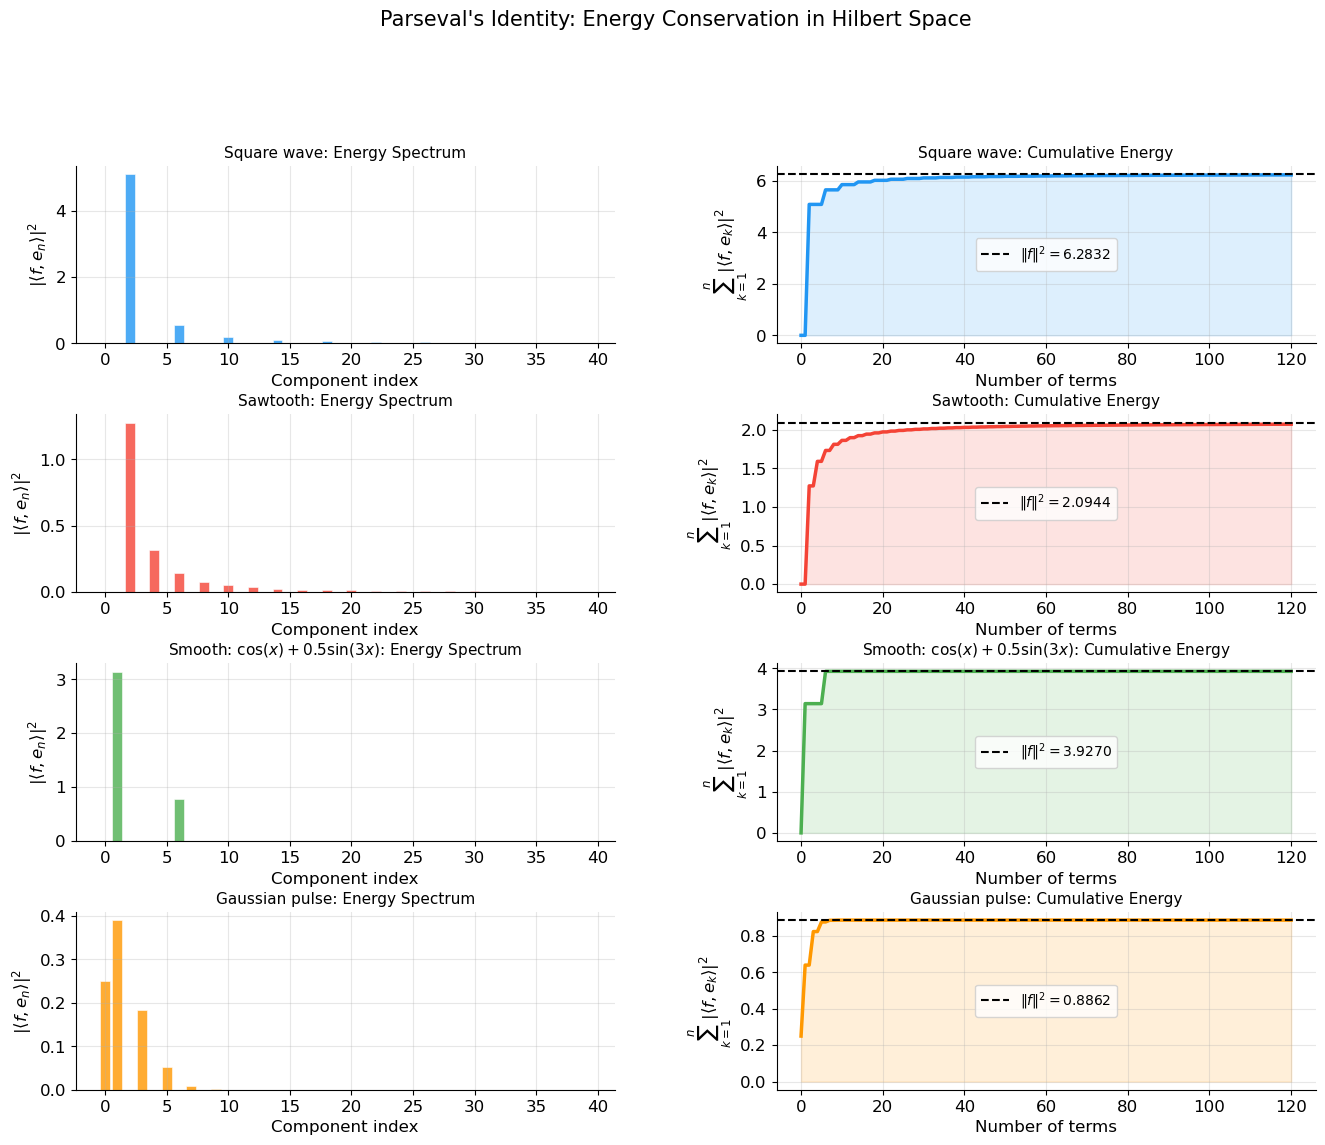

In [14]:
# Visualization: Energy spectrum and cumulative energy for each signal

fig = plt.figure(figsize=(16, 12))
gs = GridSpec(4, 2, figure=fig, hspace=0.4, wspace=0.3)

for idx, (name, (energies, cumulative, total_energy, labels)) in enumerate(all_energy_data.items()):
    # Left column: energy spectrum (bar chart)
    ax_spec = fig.add_subplot(gs[idx, 0])
    n_show = min(40, len(energies))
    bars = ax_spec.bar(range(n_show), energies[:n_show], color=PALETTE[idx], alpha=0.8,
                       edgecolor='white', linewidth=0.5)
    ax_spec.set_xlabel('Component index')
    ax_spec.set_ylabel('$|\\langle f, e_n \\rangle|^2$')
    ax_spec.set_title(f'{name}: Energy Spectrum', fontsize=11)
    
    # Right column: cumulative energy vs ||f||^2
    ax_cum = fig.add_subplot(gs[idx, 1])
    ax_cum.plot(range(len(cumulative)), cumulative, color=PALETTE[idx], linewidth=2.5)
    ax_cum.axhline(y=total_energy, color='black', linestyle='--', linewidth=1.5,
                   label=f'$\\|f\\|^2 = {total_energy:.4f}$')
    ax_cum.fill_between(range(len(cumulative)), cumulative, alpha=0.15, color=PALETTE[idx])
    ax_cum.set_xlabel('Number of terms')
    ax_cum.set_ylabel('$\\sum_{k=1}^{n} |\\langle f, e_k \\rangle|^2$')
    ax_cum.set_title(f'{name}: Cumulative Energy', fontsize=11)
    ax_cum.legend(fontsize=10)

fig.suptitle("Parseval's Identity: Energy Conservation in Hilbert Space",
             fontsize=15, y=1.01)
plt.tight_layout()
plt.show()

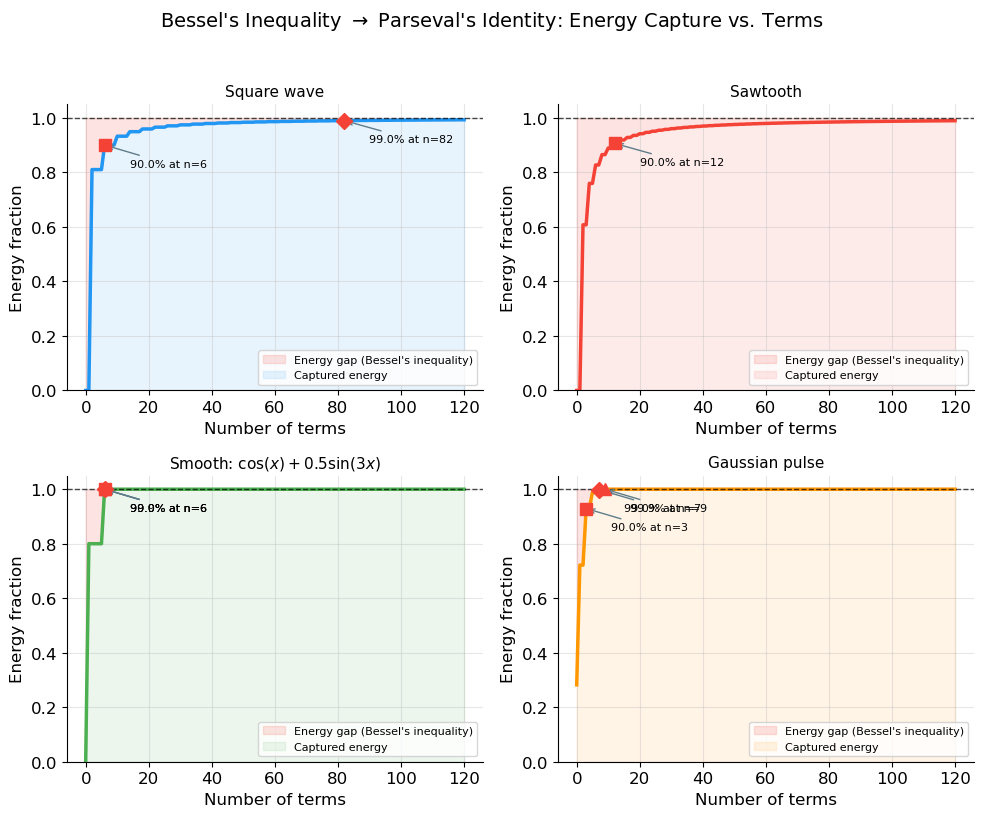

In [15]:
# Detailed comparison: Bessel vs Parseval
# Show how the inequality becomes an equality as we use more terms

fig, axes = plt.subplots(2, 2, figsize=FIGSIZE_TALL)
axes = axes.ravel()

for idx, (name, (energies, cumulative, total_energy, _)) in enumerate(all_energy_data.items()):
    ax = axes[idx]
    
    ratio = cumulative / total_energy
    
    ax.plot(range(len(ratio)), ratio, color=PALETTE[idx], linewidth=2.5)
    ax.axhline(y=1.0, color='black', linestyle='--', linewidth=1, alpha=0.7)
    ax.fill_between(range(len(ratio)), ratio, 1.0, alpha=0.15, color=C_RED,
                    label='Energy gap (Bessel\'s inequality)')
    ax.fill_between(range(len(ratio)), 0, ratio, alpha=0.1, color=PALETTE[idx],
                    label='Captured energy')
    
    # Find N where we capture 90%, 99%, 99.9%
    for threshold, marker in [(0.90, 's'), (0.99, 'D'), (0.999, '^')]:
        idx_thresh = np.argmax(ratio >= threshold)
        if ratio[idx_thresh] >= threshold:
            ax.plot(idx_thresh, ratio[idx_thresh], marker, color=C_RED, markersize=8,
                    zorder=5)
            ax.annotate(f'{threshold*100:.1f}% at n={idx_thresh}',
                       xy=(idx_thresh, ratio[idx_thresh]),
                       xytext=(idx_thresh + 8, ratio[idx_thresh] - 0.08),
                       fontsize=8, arrowprops=dict(arrowstyle='->', color=C_GREY))
    
    ax.set_xlabel('Number of terms')
    ax.set_ylabel('Energy fraction')
    ax.set_title(name, fontsize=11)
    ax.set_ylim(0, 1.05)
    ax.legend(fontsize=8, loc='lower right')

fig.suptitle('Bessel\'s Inequality $\\to$ Parseval\'s Identity: Energy Capture vs. Terms',
             fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

Generalized Parseval: <f, g> = sum <f, e_n> * conj(<g, e_n>)
  <f, g> (direct integration):         1.3804038618
  sum <f,e_n><g,e_n> (N=100 terms): 1.3804038618
  Absolute difference:                  2.22e-16


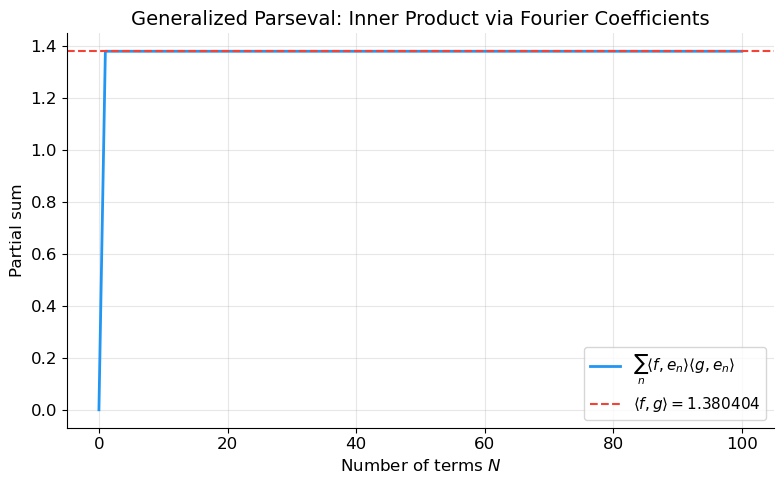

In [16]:
# Final visualization: the isometric isomorphism H -> ell^2
# Show that the Fourier coefficient map preserves inner products

print("Generalized Parseval: <f, g> = sum <f, e_n> * conj(<g, e_n>)")
print("=" * 65)

# Define two functions
f1 = np.exp(-x_p**2)                # Gaussian
f2 = np.cos(x_p) + 0.3*np.sin(2*x_p)  # Trig combination

# Direct inner product
direct_ip = np.trapezoid(f1 * f2, x_p)

# Via Fourier coefficients
N_check = 100
fourier_ip = 0.0
convergence = []

# Constant term
c1_0 = np.trapezoid(f1 / np.sqrt(2*np.pi), x_p)
c2_0 = np.trapezoid(f2 / np.sqrt(2*np.pi), x_p)
fourier_ip += c1_0 * c2_0
convergence.append(fourier_ip)

for n in range(1, N_check + 1):
    cos_n = np.cos(n * x_p) / np.sqrt(np.pi)
    sin_n = np.sin(n * x_p) / np.sqrt(np.pi)
    
    fc1 = np.trapezoid(f1 * cos_n, x_p)
    fc2 = np.trapezoid(f2 * cos_n, x_p)
    fs1 = np.trapezoid(f1 * sin_n, x_p)
    fs2 = np.trapezoid(f2 * sin_n, x_p)
    
    fourier_ip += fc1*fc2 + fs1*fs2
    convergence.append(fourier_ip)

print(f"  <f, g> (direct integration):         {direct_ip:.10f}")
print(f"  sum <f,e_n><g,e_n> (N={N_check} terms): {fourier_ip:.10f}")
print(f"  Absolute difference:                  {abs(direct_ip - fourier_ip):.2e}")

fig, ax = plt.subplots(figsize=FIGSIZE_SMALL)
ax.plot(range(len(convergence)), convergence, color=C_BLUE, linewidth=2,
        label=r'$\sum_{n} \langle f,e_n\rangle \langle g,e_n\rangle$')
ax.axhline(y=direct_ip, color=C_RED, linestyle='--', linewidth=1.5,
           label=f'$\\langle f, g \\rangle = {direct_ip:.6f}$')
ax.set_xlabel('Number of terms $N$')
ax.set_ylabel('Partial sum')
ax.set_title('Generalized Parseval: Inner Product via Fourier Coefficients')
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

**Summary of energy results:**

1. **Bessel's inequality** ($\sum |\langle f, e_n \rangle|^2 \leq \|f\|^2$) holds for any ONS, with the gap representing energy in components "not seen" by the ONS.
2. **Parseval's identity** ($\sum |\langle f, e_n \rangle|^2 = \|f\|^2$) holds when the ONS is complete (an ONB), meaning all energy is accounted for.
3. **Smooth functions** (Gaussian) have rapidly decaying Fourier coefficients, so a few terms capture most energy. **Discontinuous functions** (square wave) have slowly decaying coefficients, requiring many terms.
4. The generalized Parseval identity confirms that inner products are preserved by the Fourier coefficient map, establishing the **isometric isomorphism** $H \cong \ell^2$.

---

## Summary

| Concept | Key Result | Why It Matters |
|---------|-----------|----------------|
| Inner Product | Cauchy-Schwarz, Parallelogram law | Geometry: angles, lengths, orthogonality |
| Hilbert Space | Complete inner product space | "Nice" infinite-dimensional geometry |
| Orthogonality | Gram-Schmidt, ONB | Coordinate systems in function spaces |
| Projection Theorem | Unique closest point in closed subspaces | Best approximation (Fourier, least squares) |
| Riesz Representation | $H \cong H^*$ | Every functional is an inner product |
| Parseval's Identity | $\|f\|^2 = \sum |\hat{f}_n|^2$ | Energy conservation, $H \cong \ell^2$ |

The central theme: **Hilbert spaces are the spaces where infinite-dimensional linear algebra works as well as finite-dimensional linear algebra.** The inner product provides geometry, completeness ensures limits exist, and the Riesz theorem guarantees a perfect duality.

---

## References

1. **Kreyszig, E.** *Introductory Functional Analysis with Applications.* Wiley, 1978. (Chapters 3, 4 -- Hilbert spaces, orthogonal expansions)
2. **Conway, J.B.** *A Course in Functional Analysis.* Springer, 2nd edition, 1990. (Chapter II -- Hilbert spaces)
3. **Rudin, W.** *Real and Complex Analysis.* McGraw-Hill, 3rd edition, 1987. (Chapter 4 -- Hilbert spaces)
4. **Young, N.** *An Introduction to Hilbert Space.* Cambridge University Press, 1988. (Accessible undergraduate treatment)
5. **Brezis, H.** *Functional Analysis, Sobolev Spaces and Partial Differential Equations.* Springer, 2011. (Chapter 5 -- Hilbert spaces)
6. **Stein, E.M. & Shakarchi, R.** *Fourier Analysis: An Introduction.* Princeton University Press, 2003. (Fourier series and convergence)
7. **Axler, S.** *Linear Algebra Done Right.* Springer, 4th edition, 2024. (Inner product spaces and orthogonality in finite dimensions)